look at the properties of modules

In [1]:
def module_to_dict(file=""):
    # importing the module
    import json
     
    # Opening JSON file
    with open(file, 'r') as json_file:
        data = json.load(json_file)
        return data  

In [2]:
def get_distribution(data):
    power_law = False
    exponential = False
    log_normal = False
    import numpy as np
    from scipy.stats import powerlaw, expon, lognorm
    # Fit data to a power-law distribution
    alpha, loc, scale = powerlaw.fit(data)
    # Fit data to an exponential distribution
    loc, scale = expon.fit(data)
    # Fit data to a log-normal distribution
    shape, loc, scale = lognorm.fit(data)
    
    from scipy.stats import kstest
    # Perform KS test for power-law distribution
    ks_stat, p_value = kstest(data, powerlaw(alpha, loc, scale).cdf)
    if p_value < 0.05:
        print("power law")
        power_law = True
    # Perform KS test for exponential distribution
    ks_stat, p_value = kstest(data, expon(loc, scale).cdf)
    if p_value < 0.05:
        print("exponential")
        exponential = True
    # Perform KS test for log-normal distribution
    ks_stat, p_value = kstest(data, lognorm(shape, loc, scale).cdf)
    if p_value < 0.05:
        print("log normal")
        log_normal = True

    return power_law, exponential, log_normal

In [3]:
def module_size_distribution(module_dict):
    import matplotlib.pyplot as plt
    # Extract module sizes from the dictionary
    module_sizes = [len(module) for module in module_dict.values()]
    power_law, exponential, log_normal = get_distribution(data=module_sizes)
    # Create a figure and axis object
    fig, ax = plt.subplots()
    # Plot histogram of module sizes
    plt.hist(module_sizes, bins=range(min(module_sizes), max(module_sizes) + 1), edgecolor='black')
    
    # Increase x and y axes tick sizes
    # Increase font size of major tick labels on both axes
    ax.tick_params(axis='both', which='major', labelsize=16)

    plt.xlabel('Module Size', fontsize=18)
    plt.ylabel('Frequency', fontsize=18)
    plt.title('Distribution of Module Sizes', fontsize=20)
    # Add text to indicate distribution types
    plt.text(0.7, 0.9, f'PL = {power_law}', transform=plt.gca().transAxes, color='orange', fontsize=18)
    plt.text(0.7, 0.8, f'Ex = {exponential}', transform=plt.gca().transAxes, color='orange', fontsize=18)
    plt.text(0.7, 0.7, f'LN = {log_normal}', transform=plt.gca().transAxes, color='orange', fontsize=18)
    
    plt.show()

401
793
power law
exponential
log normal


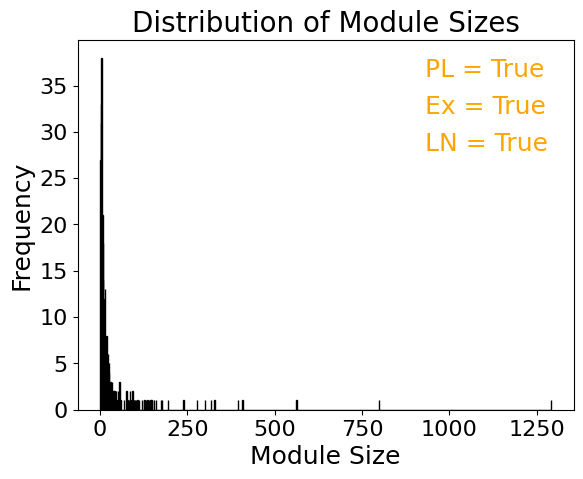

power law
exponential
log normal


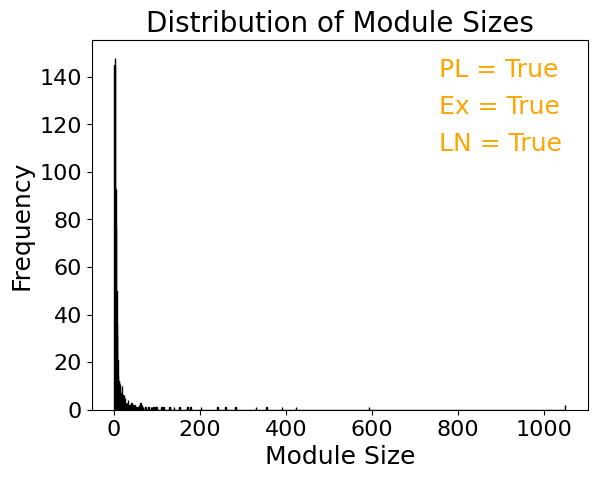

In [4]:
module_I = module_to_dict("my_module_I.json")
module_IV = module_to_dict("my_module_IV.json")
print(len(module_I))
print(len(module_IV))
module_size_distribution(module_dict=module_I)
module_size_distribution(module_dict=module_IV)

neighbors = 10, resolution = 20

310
307
power law
exponential


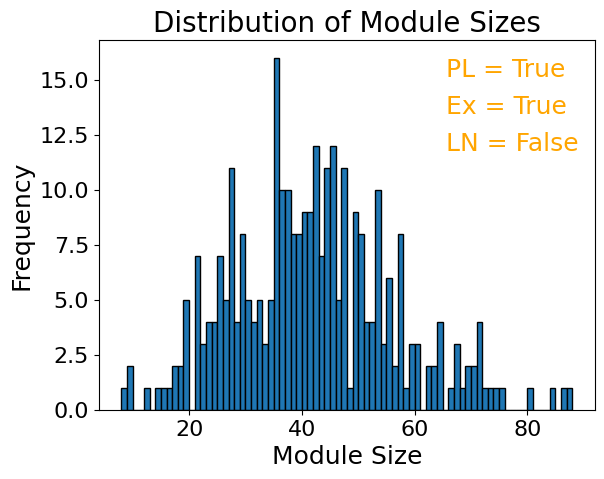

power law
exponential


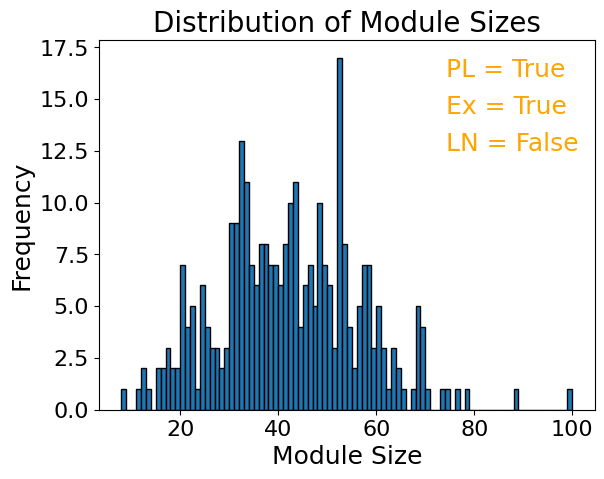

In [5]:
module_I = module_to_dict("module_I.json")
module_IV = module_to_dict("module_IV.json")
print(len(module_I))
print(len(module_IV))
module_size_distribution(module_dict=module_I)
module_size_distribution(module_dict=module_IV)